# Question Sampling for Human Study (Control Questions)

Goal: select a manageable subset of questions (~100–150) from the 1K VQA control set
that are most informative for human data collection.

## Sampling Criteria

| Tier | Criterion | Rationale |
|------|-----------|-----------|
| A | **Overconfident & Wrong** | High model confidence + low accuracy = hallucination signal |
| B | **Answer Flip across variants** | Model changes answer when question is weakened = genuine linguistic sensitivity |
| C | **Cross-model consensus wrong** | All models give same wrong answer = shared corpus prior |
| D | **High degradation** | Large accuracy drop from `question` → `subject_ablated` = shortcut dependent |
| E | **Stratified by answer type** | Ensure coverage of yes/no, number, color, location, other |

Target: ~30 questions per tier, stratified by answer type, final deduplicated set of ~100–150.

In [1]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR   = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated']

# Load entity grouping from semantics
sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = sem_df.set_index('question_id')['ent'].to_dict()
print("Entity categories:", sorted(sem_df['ent'].dropna().unique()))


Entity categories: ['animal', 'food', 'object', 'other', 'person', 'place', 'product', 'text', 'vehicle']


In [2]:
def load_control(model, dataset='vqa_1k_control'):
    filepath = f'{RESULTS_DIR}/{model}/{dataset}.jsonl'
    if not os.path.exists(filepath):
        return []
    rows = []
    with open(filepath) as f:
        for line in f:
            ex = json.loads(line)
            if 'generated_logits' not in ex:
                continue
            gt_answers = mapper.get_answers(ex['question_id'])
            output_key = 'generated_answers' if 'generated_answers' in ex else 'answers'
            ent = qid_to_ent.get(ex['question_id'], 'other')
            for ct in ex['generated_logits']:
                logits = ex['generated_logits'][ct]['content']
                token_probs = np.exp([t['logprob'] for t in logits])
                confidence = float(token_probs.mean())
                output = ex[output_key].get(ct, '')
                accuracy = vqa_accuracy(output, gt_answers) if gt_answers else None
                rows.append({
                    'model': model,
                    'question_id': ex['question_id'],
                    'control_type': ct,
                    'question_text': ex.get(ct, ''),
                    'output': output,
                    'confidence': confidence,
                    'accuracy': accuracy,
                    'ent': ent,
                    'gt_answer': gt_answers
                })
    return rows

models = [m for m in os.listdir(RESULTS_DIR)
          if os.path.exists(f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl')]
print('Models found:', models)

all_rows = []
for m in models:
    all_rows.extend(load_control(m))

df = pd.DataFrame(all_rows)
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')
print(f'Loaded {len(df)} rows | {df["model"].nunique()} models | {df["question_id"].nunique()} questions')
print(f'\nEntity distribution:\n{df[df["control_type"]=="question"]["ent"].value_counts()}')


Models found: ['Qwen3-VL-32B-Instruct', 'llava-v1.6-vicuna-7b-hf', 'llava-v1.6-vicuna-13b-hf', 'llava-1.5-7b-hf', 'Qwen3-VL-4B-Instruct', 'llava-v1.6-mistral-7b-hf', 'Qwen3-VL-8B-Instruct']
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded 25215 rows | 6 models | 1000 questions

Entity distribution:
ent
object     1741
person     1168
animal      540
other       423
food        391
place       302
vehicle     261
text        131
product      86
Name: count, dtype: int64


In [ ]:
df.groupby(['question_id', 'control_type', 'ent', 'gt_answer']).

In [11]:
df.model.unique()

<ArrowStringArray>
[   'Qwen3-VL-32B-Instruct',  'llava-v1.6-vicuna-7b-hf',
 'llava-v1.6-vicuna-13b-hf',          'llava-1.5-7b-hf',
 'llava-v1.6-mistral-7b-hf',     'Qwen3-VL-8B-Instruct']
Length: 6, dtype: str

In [13]:
# Aggregate per (question_id, control_type) across models
agg = df[df['model'].isin(['llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf',  'llava-v1.6-vicuna-7b-hf',   'Qwen3-VL-8B-Instruct'])].groupby(['question_id', 'control_type', 'ent']).agg(
    mean_accuracy=('accuracy', 'mean'),
    mean_confidence=('confidence', 'mean'),
    n_models=('model', 'nunique'),
    outputs=('output', lambda x: list(x)),
).reset_index()

# Per question: baseline (original question) and most-weakened (subject_ablated)
baseline = agg[agg['control_type'] == 'question'][['question_id', 'mean_accuracy', 'mean_confidence', 'ent']]
baseline.columns = ['question_id', 'acc_baseline', 'conf_baseline', 'ent']
ablated = agg[agg['control_type'] == 'subject_ablated'][['question_id', 'mean_accuracy', 'mean_confidence']]
ablated.columns = ['question_id', 'acc_ablated', 'conf_ablated']

qdf = baseline.merge(ablated, on='question_id')
qdf['acc_drop']  = qdf['acc_baseline']  - qdf['acc_ablated']
qdf['conf_drop'] = qdf['conf_baseline'] - qdf['conf_ablated']   # Tier E

# Tier A — overconfident & wrong
qdf['overconfident_wrong'] = (qdf['conf_baseline'] > 0.75) & (qdf['acc_baseline'] < 0.2)

# Tier B — answer flip across control variants
flip = df.groupby(['question_id', 'model']).apply(
    lambda g: g.set_index('control_type')['output'].reindex(CONTROL_TYPES).nunique(dropna=True)
).reset_index()
flip.columns = ['question_id', 'model', 'n_unique_outputs']
flip_agg = flip.groupby('question_id')['n_unique_outputs'].mean().reset_index()
flip_agg.columns = ['question_id', 'mean_output_changes']

# Tier C — majority of models wrong on baseline (relaxed: no requirement for same answer)
consensus = (
    df[df['control_type'] == 'question']
    .groupby('question_id')
    .apply(lambda g: (g['accuracy'] < 0.2).mean())
    .reset_index()
)
consensus.columns = ['question_id', 'frac_models_wrong']
consensus['consensus_wrong'] = consensus['frac_models_wrong'] >= 0.8

qdf = qdf.merge(flip_agg, on='question_id').merge(
    consensus[['question_id', 'consensus_wrong', 'frac_models_wrong']], on='question_id'
)
qdf.head()

,question_id,acc_baseline,conf_baseline,ent,acc_ablated,conf_ablated,acc_drop,conf_drop,overconfident_wrong,mean_output_changes,consensus_wrong,frac_models_wrong
0,589013,1.000000,0.872040,other,1.000000,0.872040,0.0,0.000000,False,1.000000,False,0.000000
1,757004,0.916667,0.856617,animal,0.916667,0.863229,0.0,-0.006613,False,1.166667,False,0.000000
2,1342072,0.000000,0.698225,other,0.000000,0.708453,0.0,-0.010228,False,1.833333,True,1.000000
3,2006001,1.000000,0.901612,vehicle,1.000000,0.899090,0.0,0.002522,False,1.333333,False,0.166667
4,2521002,0.666667,0.848073,object,0.666667,0.834765,0.0,0.013308,False,1.166667,False,0.000000


=== Criterion Counts ===
A. Overconfident & Wrong (conf>0.75, acc<0.2):        35
B. Answer flip (mean unique outputs > 2):             88
C. Consensus wrong (≥80% models wrong on baseline):  63
D. High accuracy drop (acc_drop > 0.3):              158
E. High confidence drop (conf_drop > 0.05):          205
   — of which: confident→uncertain despite correct:  177

Entity distribution (all 1K questions):
ent
object     344
person     232
animal     107
other       84
food        78
place       60
vehicle     52
text        26
product     17
Name: count, dtype: int64


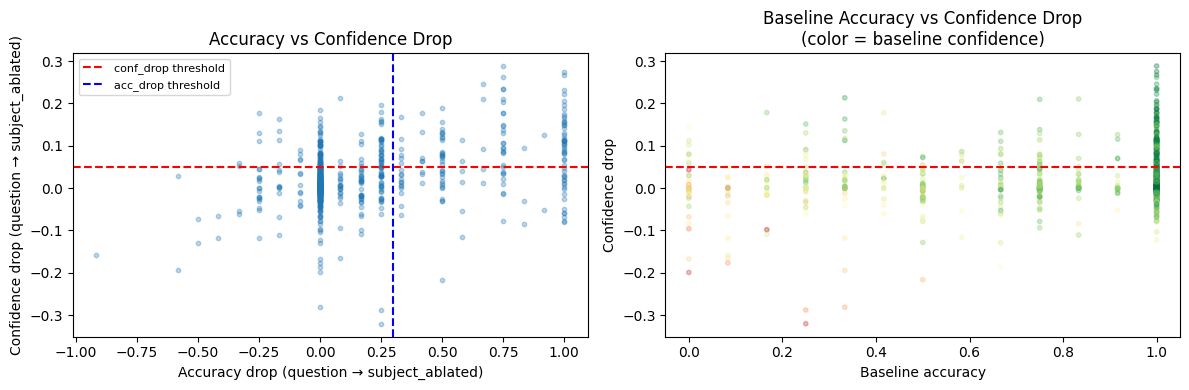

In [14]:
print('=== Criterion Counts ===')
print(f"A. Overconfident & Wrong (conf>0.75, acc<0.2):        {qdf['overconfident_wrong'].sum()}")
print(f"B. Answer flip (mean unique outputs > 2):             {(qdf['mean_output_changes'] > 2).sum()}")
print(f"C. Consensus wrong (≥80% models wrong on baseline):  {qdf['consensus_wrong'].sum()}")
print(f"D. High accuracy drop (acc_drop > 0.3):              {(qdf['acc_drop'] > 0.3).sum()}")
print(f"E. High confidence drop (conf_drop > 0.05):          {(qdf['conf_drop'] > 0.05).sum()}")
print(f"   — of which: confident→uncertain despite correct:  "
      f"{((qdf['conf_drop'] > 0.05) & (qdf['acc_baseline'] > 0.5)).sum()}")
print()
print('Entity distribution (all 1K questions):')
print(qdf['ent'].value_counts())

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(qdf['acc_drop'], qdf['conf_drop'], alpha=0.3, s=10)
axes[0].axhline(0.05, color='r', linestyle='--', label='conf_drop threshold')
axes[0].axvline(0.3, color='b', linestyle='--', label='acc_drop threshold')
axes[0].set_xlabel('Accuracy drop (question → subject_ablated)')
axes[0].set_ylabel('Confidence drop (question → subject_ablated)')
axes[0].set_title('Accuracy vs Confidence Drop')
axes[0].legend(fontsize=8)

axes[1].scatter(qdf['acc_baseline'], qdf['conf_drop'], alpha=0.3, s=10, c=qdf['conf_baseline'], cmap='RdYlGn')
axes[1].axhline(0.05, color='r', linestyle='--')
axes[1].set_xlabel('Baseline accuracy')
axes[1].set_ylabel('Confidence drop')
axes[1].set_title('Baseline Accuracy vs Confidence Drop\n(color = baseline confidence)')
plt.tight_layout()
plt.show()


In [15]:
np.random.seed(42)

N_PER_TIER = 30

def stratified_sample(mask, n, ent_col='ent', seed=42):
    """Sample n questions from mask, stratified by entity group."""
    pool = qdf[mask].copy()
    if len(pool) == 0:
        print("  → empty pool, skipping")
        return []
    counts = pool[ent_col].value_counts(normalize=True)
    sampled = []
    for ent, frac in counts.items():
        k = max(1, round(n * frac))
        sub = pool[pool[ent_col] == ent]
        sampled.extend(sub.sample(min(k, len(sub)), random_state=seed)['question_id'].tolist())
    return list(set(sampled))[:n]

tier_A = stratified_sample(qdf['overconfident_wrong'],        N_PER_TIER)
tier_B = stratified_sample(qdf['mean_output_changes'] > 2,    N_PER_TIER)
tier_C = stratified_sample(qdf['consensus_wrong'],            N_PER_TIER)
tier_D = stratified_sample(qdf['acc_drop'] > 0.3,            N_PER_TIER)
tier_E = stratified_sample(qdf['conf_drop'] > 0.05,          N_PER_TIER)

# Combine, deduplicate, label tiers
all_sampled = {}
for qid in tier_A: all_sampled[qid] = all_sampled.get(qid, []) + ['A_overconfident_wrong']
for qid in tier_B: all_sampled[qid] = all_sampled.get(qid, []) + ['B_answer_flip']
for qid in tier_C: all_sampled[qid] = all_sampled.get(qid, []) + ['C_consensus_wrong']
for qid in tier_D: all_sampled[qid] = all_sampled.get(qid, []) + ['D_high_acc_drop']
for qid in tier_E: all_sampled[qid] = all_sampled.get(qid, []) + ['E_high_conf_drop']

sampled_df = pd.DataFrame([
    {'question_id': qid, 'tiers': '|'.join(tiers)}
    for qid, tiers in all_sampled.items()
])
sampled_df = sampled_df.merge(qdf, on='question_id')
sampled_df['n_tiers'] = sampled_df['tiers'].str.count(r'\|') + 1
sampled_df = sampled_df.sort_values('n_tiers', ascending=False)

print(f'Total unique questions selected: {len(sampled_df)}')
print(f'Questions in multiple tiers:     {(sampled_df["n_tiers"] > 1).sum()}')
print()
print('Entity distribution in sample:')
print(sampled_df['ent'].value_counts())
print()
print('Tier breakdown:')
for tier in ['A_overconfident_wrong', 'B_answer_flip', 'C_consensus_wrong', 'D_high_acc_drop', 'E_high_conf_drop']:
    print(f'  {tier}: {sampled_df["tiers"].str.contains(tier).sum()}')


Total unique questions selected: 123
Questions in multiple tiers:     25

Entity distribution in sample:
ent
object     57
person     24
animal     10
food        8
vehicle     7
place       6
other       5
text        4
product     2
Name: count, dtype: int64

Tier breakdown:
  A_overconfident_wrong: 30
  B_answer_flip: 30
  C_consensus_wrong: 30
  D_high_acc_drop: 30
  E_high_conf_drop: 30


In [19]:
question_texts

,question_id,question_text
0,524577006,Question: Question: What number of clocks are ...
5,524577024,Question: Where is the clock located? Answer t...
10,524577027,Question: What type of numbers are on the cloc...
15,524799000,Question: How old is the child? Answer the que...
20,524850001,Question: How many engines do you see? Answer ...
...,...,...
5190,130732000,Question: What yellow thing is lying on the si...
5195,392878005,Question: Where are the folks sitting? Answer ...
5200,392915002,Question: Is the room sunny? Answer the questi...
5205,262048001,Question: Where are these people at? Answer th...


In [ ]:
# Attach question text and all model outputs for manual review
question_texts = df[df['control_type'] == 'question'][['question_id', 'question_text', 'gt_answer']].drop_duplicates('question_id') 
outputs_pivot = df[
    (df['question_id'].isin(sampled_df['question_id'])) &
    (df['control_type'] == 'question')
].pivot_table(index='question_id', columns='model', values='output', aggfunc='first').reset_index()

review_df = sampled_df.merge(question_texts, on='question_id').merge(outputs_pivot, on='question_id')

display_cols = ['question_id', 'ent', 'tiers', 'n_tiers', 'acc_baseline', 'acc_drop',
                'conf_baseline', 'frac_models_wrong', 'question_text', 'gt_answer'] + list(outputs_pivot.columns[1:])
review_df[display_cols].head(20) 

,question_id,ent,tiers,n_tiers,acc_baseline,acc_drop,conf_baseline,frac_models_wrong,question_text,gt_answer,Qwen3-VL-32B-Instruct,Qwen3-VL-8B-Instruct,llava-1.5-7b-hf,llava-v1.6-mistral-7b-hf,llava-v1.6-vicuna-13b-hf,llava-v1.6-vicuna-7b-hf
0,72096002,object,A_overconfident_wrong|B_answer_flip|C_consensu...,3,0.083333,0.083333,0.763202,0.8,Question: What part of the tablecloth flowers ...,"[ivy, flower leaves, flowers, leaves, leaves, ...",NaN,none,Center,Flowers,Roses,Tablecloth
1,13769009,place,A_overconfident_wrong|B_answer_flip|C_consensu...,3,0.000000,0.000000,0.848162,1.0,Question: What is this bathroom missing? Answe...,"[door, sink, yes, door, sink, door, door, no, ...",NaN,toilet paper,Toilet paper,Toilet paper,Toilet paper,Toilet paper
2,345711000,place,D_high_acc_drop|E_high_conf_drop,2,0.750000,0.500000,0.754743,0.2,Question: Which direction is E 42 St? Answer t...,"[to right, right, right, right, east, east, ea...",NaN,east,Right,Left,Right,Right
3,6712002,place,B_answer_flip|D_high_acc_drop,2,1.000000,0.833333,0.881320,0.0,Question: What color is the house? Answer the ...,"[blue, blue, white, blue, white, blue, blue, b...",NaN,blue,Blue,Blue,Blue,Blue
4,291990001,text,D_high_acc_drop|E_high_conf_drop,2,0.750000,0.750000,0.907725,0.0,Question: What street is this? Answer the ques...,"[35th ave, 35th ave, 35th avenue, 35th, 35 ave...",NaN,35th avenue,35th ave,35th ave,35th,35th ave
5,124601004,food,B_answer_flip|D_high_acc_drop,2,1.000000,1.000000,0.990322,0.0,Question: How many oranges are there? Answer t...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",NaN,0,0,0,0,0
6,512760019,object,D_high_acc_drop|E_high_conf_drop,2,1.000000,0.750000,0.958677,0.0,Question: What color are the cabinets? Answer ...,"[brown, brown, brown, brown, brown, dark brown...",NaN,brown,Brown,Brown,Brown,Brown
7,237263001,object,B_answer_flip|E_high_conf_drop,2,1.000000,1.000000,0.855459,0.0,Question: What is the table made of? Answer th...,"[granite, marble, marble, marble, marble, wood...",NaN,marble,Marble,Marble,Marble,Marble
8,252625003,object,B_answer_flip|E_high_conf_drop,2,0.750000,0.416667,0.773436,0.2,Question: What color are the crates against th...,"[yellow, red, white, and yellow, red, white an...",NaN,yellow,Yellow,Yellow,Yellow,Red
9,166586001,object,B_answer_flip|C_consensus_wrong,2,0.083333,0.083333,0.645789,0.8,Question: What does the series of photographs ...,"[picking fruit, harvesting, harvesting, farmin...",NaN,banana harvest,Market,Farming,Market,Market


In [7]:
# Export for manual review / human study design
out_path = '/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv'
review_df.to_csv(out_path, index=False)
print(f'Saved {len(review_df)} questions to {out_path}')

# Summary by tier
print('\n=== Tier Breakdown ===')
for tier in ['A_overconfident_wrong', 'B_answer_flip', 'C_consensus_wrong', 'D_high_degradation']:
    n = sampled_df['tiers'].str.contains(tier).sum()
    print(f'  {tier}: {n} questions')

Saved 120 questions to /home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv

=== Tier Breakdown ===
  A_overconfident_wrong: 26 questions
  B_answer_flip: 30 questions
  C_consensus_wrong: 30 questions
  D_high_degradation: 0 questions
